In [1]:
from learn_to_infer import Worker
from task import SwitchingBandit
import pandas as pd
import torch
import numpy as np

from matplotlib import pyplot as plt
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42


In [6]:
index = 1

self = Worker(
    SwitchingBandit(n_trials=200),
    "results/source/saved_models",
    "fullRNN_id{0}".format(index),
    optimizer="Adam",
    init_type="xavier",
    episode_count_max=5e4,
    num_units=32,
    rnn_type="GRU",
    input_type='logodds',
    learn_emission=True
)

self.load_model()

In [7]:
self.model_name

'fullRNN_id1_init_xavier_optim_Adam_episodeNbMax_50000_numUnits_32_rnnType_GRU_inputType_logodds_learnEmission_True'

In [13]:
dict(self.named_parameters()).keys()

dict_keys(['W_output_emission', 'W_output', 'initial_rnn_emission', 'initial_rnn', 'gru.weight_ih_l0', 'gru.weight_hh_l0', 'gru.bias_ih_l0', 'gru.bias_hh_l0', 'gru_emission.weight_ih_l0', 'gru_emission.weight_hh_l0', 'gru_emission.bias_ih_l0', 'gru_emission.bias_hh_l0'])

In [ ]:
dict(self.named_parameters())["gru_emission.weight_ih_l0"].shape

torch.Size([96, 3])

: 

In [77]:
# learn task A
self.env.reset(nb_tasks=1000)
result = self.evaluate(use_ground_truth=False)

In [78]:
# Sort nus into bins with equal number of points
nb_bins = 10
nus = self.env.nu.mean(axis=1)
sorted_bins = np.percentile(nus, np.linspace(0, 100, nb_bins + 1))
digited_bins = np.digitize(nus, sorted_bins) - 1
nus_native = np.zeros([nb_bins])
nus_learned = np.zeros([nb_bins])
for bin in range(nb_bins):
    print(f"Bin {bin}: {nus[digited_bins == bin].mean()}, n={np.sum(digited_bins == bin)}")
    nus_native[bin] = self.env.nu[digited_bins == bin].mean()
    nus_learned[bin] = result["params_all"][digited_bins == bin, -1].mean(axis=0).detach().numpy()

Bin 0: 0.004092503107070383, n=100
Bin 1: 0.01311548004127521, n=100
Bin 2: 0.0250671942160582, n=100
Bin 3: 0.03901977382087606, n=100
Bin 4: 0.058053075180625996, n=100
Bin 5: 0.07924529088457795, n=100
Bin 6: 0.10361356872210792, n=100
Bin 7: 0.13724995243955854, n=100
Bin 8: 0.18521761001954726, n=100
Bin 9: 0.28300920098142235, n=99


Text(0, 0.5, 'Inferred mean volatility')

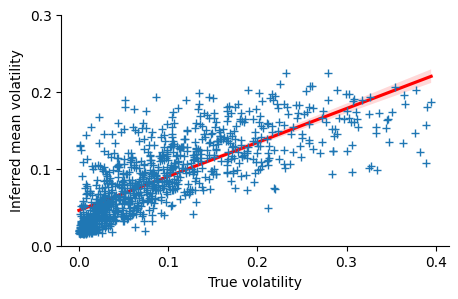

In [80]:
import seaborn as sns

nus = self.env.nu.mean(axis=1)
inferred_vol = [(result["params_all"].mean(axis=1)[nus == nu]).detach().numpy() for nu in np.unique(nus)]
mean_vol = np.array([np.mean(v) for v in inferred_vol])
std_vol = np.array([np.std(v) for v in inferred_vol])

plt.figure(figsize=(5, 3))
plt.errorbar(np.unique(nus), mean_vol, yerr=std_vol, capsize=0, capthick=0, linestyle='None', marker='+')

# Add linear regression with confidence interval
unique_nus = np.unique(nus)
sns.regplot(x=unique_nus, y=mean_vol, scatter=False, color='red')

plt.ylim([0, 0.3])
plt.gca().set_yticks([0,  0.1, 0.2, 0.3])
plt.gca().set_xticks([0,  0.1, 0.2, 0.3, 0.4])
plt.gca().spines[['right', 'top']].set_visible(False)
plt.xlabel('True volatility')
plt.ylabel('Inferred mean volatility')

In [81]:
# Sort llrmaxs into 10 bins and return bin indices
nb_bins = 5
sorted_bins = np.linspace(self.env.llrmaxs.min(), self.env.llrmaxs.max(), nb_bins + 1)
digited_bins = np.digitize(self.env.llrmaxs, sorted_bins) - 1
p_gen_native = np.zeros([nb_bins, 101])
p_gen_learned = np.zeros([nb_bins, 101])
false_positive_rate = np.zeros([nb_bins])
for bin in range(nb_bins):
    print(f"Bin {bin}: {self.env.llrmaxs[digited_bins == bin].mean()}, n={np.sum(digited_bins == bin)}")
    p_gen_native[bin] = self.env.p_gen[digited_bins == bin].mean(axis=0)
    p_gen_learned[bin] = result['params_emission'][digited_bins == bin, -1].mean(axis=0).detach().numpy()
    false_positive_rate[bin] = self.env.p_gen[digited_bins == bin].mean(axis=0)[:50].sum()

Bin 0: 1.4417472094749701, n=199
Bin 1: 2.627572870575, n=174
Bin 2: 3.891786809795729, n=190
Bin 3: 5.168588999683821, n=209
Bin 4: 6.4082805324237455, n=227


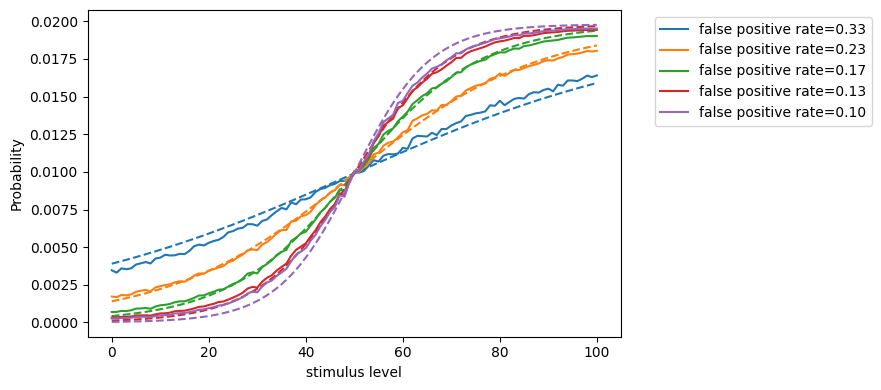

In [82]:
plt.figure(figsize=(9, 4))
for bin in range(nb_bins):
    color = f'C{bin}'
    plt.plot(p_gen_native[bin], '--', color=color)
    plt.plot(p_gen_learned[bin], color=color,
             label=f'false positive rate={false_positive_rate[bin]:.2f}')
plt.xlabel('stimulus level')
plt.ylabel('Probability')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [194]:
from scipy.stats import spearmanr, pearsonr
from tqdm import tqdm
nb_simul = 10
nb_bins = 9
nb_bins_falsefeedback = 5

out_rewards = np.zeros([nb_simul, nb_bins])
out_rewards_stds = np.zeros([nb_simul, nb_bins])
reversal_performance_means = np.zeros([nb_simul, nb_bins, 20])
reversal_performance_stds = np.zeros([nb_simul, nb_bins, 20])
emission_parameters = np.zeros([nb_simul, 101])
nus_native = np.zeros([nb_simul, nb_bins])
nus_learned = np.zeros([nb_simul, nb_bins])
nus_learned_stds = np.zeros([nb_simul, nb_bins])
nus_native_stds = np.zeros([nb_simul, nb_bins])
p_gen_native = np.zeros([nb_simul, 5, 101])
p_gen_learned = np.zeros([nb_simul,5, 101])
false_positive_rate = np.zeros([nb_simul, 5])

for index in tqdm(range(1, nb_simul + 1)):

    self = Worker(
        SwitchingBandit(n_trials=200),
        "results/source/saved_models",
        "fullRNN_id{0}".format(index),
        optimizer="Adam",
        init_type="xavier",
        episode_count_max=5e4,
        num_units=32,
        rnn_type="GRU",
        input_type='logodds',
        learn_emission=True
    )

    self.load_model(nb_episodes=4e4)        

    np.random.seed(1)
    torch.manual_seed(1)
    self.env.reset(nb_tasks=1000)
    result = self.evaluate(use_ground_truth=False)

    nus = self.env.nu.mean(axis=1)
    sorted_bins = np.percentile(nus, np.linspace(0, 100, nb_bins + 1))
    digited_bins = np.digitize(nus, sorted_bins) - 1
    for bin in range(nb_bins):
        nus_native[index - 1, bin] = self.env.nu[digited_bins == bin].mean()
        nus_native_stds[index - 1, bin] = self.env.nu[digited_bins == bin].std()
        nus_learned[index - 1, bin] = result["params_all"][digited_bins == bin, -1].mean(axis=0).detach().numpy()
        nus_learned_stds[index - 1, bin] = result["params_all"][digited_bins == bin, -1].std(axis=0).detach().numpy()        

    # rewards
    chosen_correct_action = (result['actions'].detach().numpy() == self.env.correct_arms)
    obtained_rewards = [chosen_correct_action[digited_bins == nu] for nu in range(nb_bins)]
    out_rewards[index - 1, :] = np.array([np.mean(v) for v in obtained_rewards])
    out_rewards_stds[index - 1, :] = np.array([np.std(v) for v in obtained_rewards])

    sorted_bins_falsefeedback = np.linspace(self.env.llrmaxs.min(), self.env.llrmaxs.max(), nb_bins_falsefeedback + 1)
    digited_bins_falsefeedback = np.digitize(self.env.llrmaxs, sorted_bins_falsefeedback) - 1
    for bin in range(nb_bins_falsefeedback):
        p_gen_native[index - 1, bin] = self.env.p_gen[digited_bins_falsefeedback == bin].mean(axis=0)
        p_gen_learned[index - 1, bin] = result['params_emission'][digited_bins_falsefeedback == bin, -1].mean(axis=0).detach().numpy()
        false_positive_rate[index - 1, bin] = self.env.p_gen[digited_bins_falsefeedback == bin].mean(axis=0)[:50].sum()

    # reversal performance
    chosen_correct_action = (result['actions'].detach().numpy() == self.env.correct_arms)

    reversal_xx, reversal_yy = np.where(self.env.correct_arms[:, 5:-15] != self.env.correct_arms[:, 4:-16])
    reversal_yy = reversal_yy + 5

    reversal_performance = np.zeros([nb_bins, len(reversal_xx), 20]) + np.nan
    for i, (xx, yy) in enumerate(zip(reversal_xx, reversal_yy)):
        if digited_bins[xx] != digited_bins.max():
            reversal_performance[digited_bins[xx], i, :] = chosen_correct_action[xx, (yy-5):(yy+15)]
    reversal_performance_means[index - 1, :, :] = np.nanmean(reversal_performance, axis=1)
    reversal_performance_stds[index - 1, :, :] = np.nanstd(reversal_performance, axis=1)    

100%|██████████| 10/10 [00:08<00:00,  1.14it/s]


In [195]:
sorted_bins = np.percentile(nus, np.linspace(0, 100, nb_bins + 1))
x_nus = (sorted_bins[:-1] + sorted_bins[1:]) / 2.

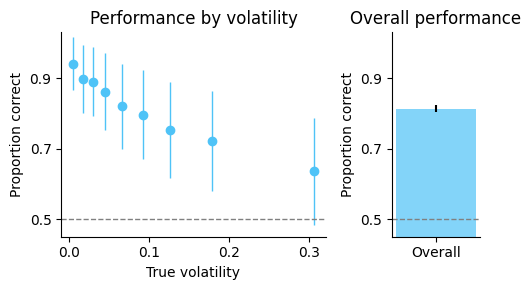

In [208]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(5, 3), gridspec_kw={'width_ratios': [3, 1]})

# Subplot 1: errorbar by volatility
mean_rewards = out_rewards.mean(axis=0)
std_rewards = out_rewards_stds.mean(axis=0) / np.sqrt(nb_simul)
axs[0].errorbar(
    x_nus,
    mean_rewards,
    yerr=std_rewards,
    fmt='o',
    color="#4FC3F7",
    ecolor="#4FC3F7",
    elinewidth=1,
    capsize=0
)
axs[0].axhline(0.5, color='gray', linestyle='--', linewidth=1)
axs[0].set_ylim([0.45, 1.03])
axs[0].set_yticks([0.5, 0.7, 0.9])
axs[0].spines[['right', 'top']].set_visible(False)
axs[0].set_xlabel('True volatility')
axs[0].set_ylabel('Proportion correct')
axs[0].set_title('Performance by volatility')

# Subplot 2: overall performance barplot
overall_mean = out_rewards.mean()
overall_std = out_rewards.std() / np.sqrt(out_rewards.size)
axs[1].bar(0, overall_mean, yerr=overall_std, color="#4FC3F7", capsize=0, alpha=0.7)
axs[1].axhline(0.5, color='gray', linestyle='--', linewidth=1)
axs[1].set_ylim([0.45, 1.03])
axs[1].set_yticks([0.5, 0.7, 0.9])
axs[1].set_xticks([0])
axs[1].set_xticklabels(['Overall'])
axs[1].spines[['right', 'top']].set_visible(False)
axs[1].set_ylabel('Proportion correct')
axs[1].set_title('Overall performance')

plt.tight_layout()
plt.savefig("figures/performance_volatility.pdf")
plt.show()

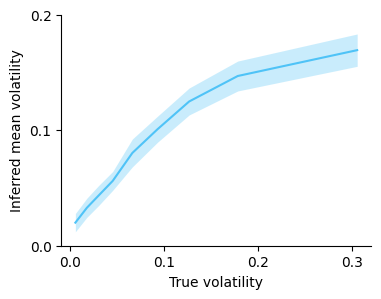

In [209]:
plt.figure(figsize=(4, 3))
mean_vol = nus_learned.mean(axis=0)
std_vol = nus_learned_stds.mean(axis=0) / np.sqrt(nb_simul)
plt.plot(x_nus, mean_vol, color="#4FC3F7")
plt.fill_between(
    x_nus,
    mean_vol - std_vol,
    mean_vol + std_vol,
    color="#4FC3F7",
    alpha=0.3,
    linewidth=0  # Remove edge
)
plt.gca().set_yticks([0, 0.1, 0.2])
plt.gca().set_xticks([0, 0.1, 0.2, 0.3])
plt.gca().spines[['right', 'top']].set_visible(False)
plt.xlabel('True volatility')
plt.ylabel('Inferred mean volatility')
plt.savefig("figures/estimated_mean_volatility.pdf")
plt.show()

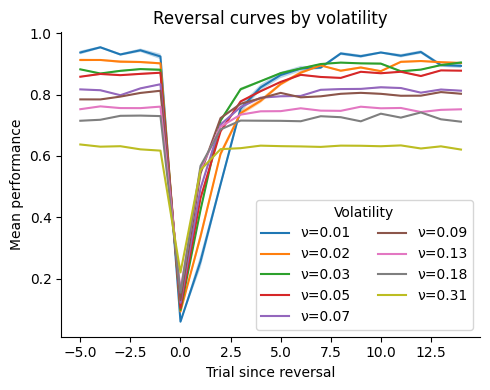

In [210]:
plt.figure(figsize=(5, 4))
for i, nu in enumerate(np.arange(nb_bins)):
    avg_reversal_performance = reversal_performance_means[:, i].mean(axis=0)
    std_reversal_performance = reversal_performance_means[:, i].std(axis=0)
    plt.plot(np.arange(-5, 15), avg_reversal_performance, label=f'ν={x_nus[i]:.2f}')
    plt.fill_between(np.arange(-5, 15), avg_reversal_performance - std_reversal_performance, avg_reversal_performance + std_reversal_performance, alpha=0.3)
plt.xlabel('Trial since reversal')
plt.ylabel('Mean performance')
plt.title('Reversal curves by volatility')
plt.legend(title='Volatility', loc='lower right', ncol=2)
plt.gca().spines[['right', 'top']].set_visible(False)
plt.tight_layout()
plt.savefig("figures/reversal_curves.pdf")
plt.show()


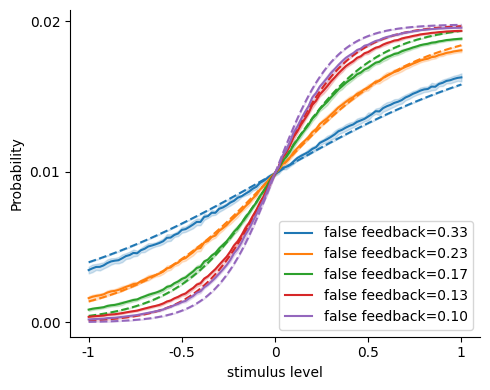

In [211]:
plt.figure(figsize=(5, 4))
for bin in range(nb_bins_falsefeedback):
    color = f'C{bin}'
    
    # Calculate mean and std across agents for native
    native_mean = p_gen_native[:, bin, :].mean(axis=0)
    native_std = p_gen_native[:, bin, :].std(axis=0)
    
    # Calculate mean and std across agents for learned
    learned_mean = p_gen_learned[:, bin, :].mean(axis=0)
    learned_std = p_gen_learned[:, bin, :].std(axis=0)
    
    # Plot native with error bands
    plt.plot(native_mean, '--', color=color)
    plt.fill_between(range(len(native_mean)), 
                    native_mean - native_std,
                    native_mean + native_std,
                    color=color, alpha=0.2)
    
    # Plot learned with error bands
    plt.plot(learned_mean, color=color,
             label=f'false feedback={false_positive_rate[0, bin]:.2f}')
    plt.fill_between(range(len(learned_mean)),
                    learned_mean - learned_std, 
                    learned_mean + learned_std,
                    color=color, alpha=0.2)

plt.xlabel('stimulus level')
plt.ylabel('Probability')
#plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.legend(loc='lower right')
plt.gca().set_yticks([0, 0.01, 0.02])
plt.gca().spines[['right', 'top']].set_visible(False)
plt.gca().set_xticks([0, 25, 50, 75, 100])
plt.gca().set_xticklabels([-1, -0.5, 0, 0.5, 1])
plt.tight_layout()
plt.savefig("figures/false_feedback_probability.pdf")
plt.show()


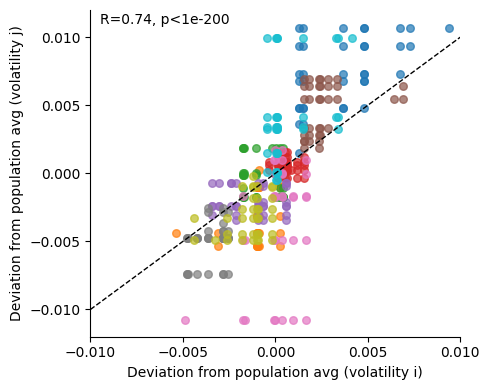

In [213]:
import itertools
from scipy.stats import pearsonr
plt.figure(figsize=(5, 4))
nb_agents, nb_volatilities = nus_learned.shape
colors = plt.cm.tab10(np.linspace(0, 1, nb_agents))

# For each agent, plot all pairs of inferred volatilities (no replacement, unordered)
all_pairs = []
for agent in range(nb_agents):
    agent_vols = nus_learned[agent]
    pairs = list(itertools.combinations(range(nb_volatilities), 2))
    x = [agent_vols[i] - nus_learned[:, i].mean() for i, j in pairs]
    y = [agent_vols[j] - nus_learned[:, j].mean() for i, j in pairs]
    plt.scatter(x, y, color=colors[agent], label=f'Agent {agent+1}', alpha=0.7, s=30)
    all_pairs.append([x, y])

all_pairs = np.array(all_pairs)
# Add x==y curve
lims = [-0.01, 0.01]
plt.plot(lims, lims, 'k--', linewidth=1, label='x = y')
plt.gca().set_xlim(lims)
plt.gca().set_ylim(lims)

plt.xlabel('Deviation from population avg (volatility i)')
plt.ylabel('Deviation from population avg (volatility j)')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.gca().set_yticks([-0.01, -0.005, 0, 0.005, 0.01])
plt.gca().set_xticks([-0.01, -0.005, 0, 0.005, 0.01])
plt.ylim([-0.012, 0.012])
#plt.legend(title='Agent', loc='lower right', fontsize='small', ncol=2)
all_pairs = np.reshape(np.swapaxes(all_pairs, 1, 2), (-1, 2))
from scipy.stats import pearsonr, spearmanr
R, p = pearsonr(all_pairs[:, 0], all_pairs[:, 1])

plt.text(-0.0095, 0.011, f"R={np.round(R, 2)}, p<1e-200")
plt.tight_layout()
plt.savefig("figures/deviation_from_mean_inferred_volatility.pdf")
plt.show()

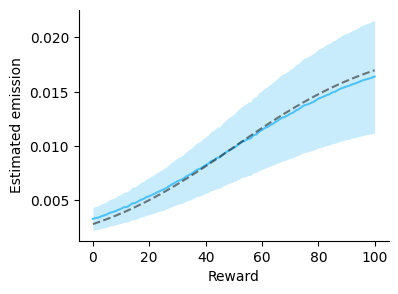

In [42]:
plt.figure(figsize=(4, 3))
mean_emission = emission_parameters.mean(axis=0)
std_emission = emission_parameters.mean(axis=0) / np.sqrt(nb_simul)
plt.plot(np.arange(101), mean_emission, color="#4FC3F7")
plt.fill_between(
    np.arange(101),
    mean_emission - std_emission,
    mean_emission + std_emission,
    color="#4FC3F7",
    alpha=0.3,
    linewidth=0  # Remove edge
)
plt.plot(np.arange(101), p_gen, 'k--', alpha=0.5)
plt.gca().spines[['right', 'top']].set_visible(False)
plt.xlabel('Reward')
plt.ylabel('Estimated emission')
plt.savefig("figures/inferred_mean_emission.pdf")
plt.show()

In [36]:
mean_emission.shape

(101,)

In [117]:
std_reversal_performance

array([0.00029429, 0.00037143, 0.00027729, 0.00033625, 0.00023015,
       0.00053953, 0.00029905, 0.00031725, 0.00029127, 0.0002217 ,
       0.00034718, 0.00011624, 0.00024973, 0.00035555, 0.00039545,
       0.00030244, 0.00026889, 0.00042569, 0.00015453, 0.0003171 ])

In [109]:
reversal_performance_means.shape

(10, 8, 20)

In [103]:
np.nanmean(reversal_performance, axis=1)

/var/folders/5j/f0qqpk592x36fxmyl_8vbkw40000gp/T/ipykernel_2540/3329227198.py:1: RuntimeWarning: Mean of empty slice
  np.nanmean(reversal_performance, axis=1)


array([[       nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan],
       [0.85585586, 0.83783784, 0.85585586, 0.85585586, 0.87387387,
        0.09459459, 0.22972973, 0.36486486, 0.44594595, 0.50900901,
        0.60810811, 0.65315315, 0.73873874, 0.7972973 , 0.84684685,
        0.83783784, 0.86036036, 0.82882883, 0.82432432, 0.83783784],
       [0.79971182, 0.79971182, 0.81556196, 0.80691643, 0.82132565,
        0.14985591, 0.28674352, 0.4092219 , 0.56772334, 0.63544669,
        0.69596542, 0.72766571, 0.74351585, 0.75792507, 0.76657061,
        0.78818444, 0.77521614, 0.79827089, 0.82564841, 0.82708934],
       [0.77137177, 0.75149105, 0.73624917, 0.75878065, 0.75016567,
        0.20079523, 0.40954274, 0.54141816, 0.63883366, 0.68323393,
        0.71040424, 0.72299536, 0.73889993, 0

In [96]:
unique_nus

array([0.  , 0.01, 0.03, 0.07, 0.1 , 0.15, 0.25, 0.4 ])

In [ ]:
(self.env.correct_arms == result['actions'].detach().numpy())

array([[ True,  True,  True, ..., False,  True, False],
       [False, False, False, ..., False, False, False],
       [ True, False,  True, ...,  True,  True,  True],
       ...,
       [False, False,  True, ...,  True, False,  True],
       [False,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True]])

In [9]:
((result3['rewarded'] * (result3['logodds'].sign()).detach()) > 0).float().mean()

NameError: name 'result3' is not defined

In [55]:
result['rewarded']

tensor([ 1.,  1., -1., -1., -1., -1., -1.,  1.,  1.,  1., -1.,  1.,  1., -1.,
         1.,  1.,  1.,  1., -1.,  1., -1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
        -1., -1.,  1.,  1.,  1.,  1., -1.,  1., -1., -1., -1.,  1.,  1.,  1.,
         1.,  1.,  1., -1.,  1.,  1.,  1.,  1., -1.,  1.,  1.,  1.,  1.,  1.,
         1.,  1.,  1., -1.,  1.,  1.,  1., -1.,  1.,  1.,  1., -1.,  1., -1.,
        -1.,  1.,  1.,  1., -1.,  1., -1., -1.,  1.,  1., -1.,  1.,  1.,  1.,
        -1.,  1.,  1.,  1., -1.,  1.,  1.,  1.,  1.,  1., -1.,  1., -1., -1.,
         1.,  1., -1., -1., -1., -1.,  1., -1.,  1., -1., -1.,  1., -1., -1.,
        -1., -1.,  1.,  1.,  1.,  1.,  1.,  1., -1., -1.,  1., -1.,  1.,  1.,
        -1.,  1.,  1.,  1.,  1., -1., -1.,  1., -1.,  1., -1.,  1., -1.,  1.,
         1.,  1.,  1.,  1., -1.,  1., -1.,  1.,  1.,  1.,  1.,  1., -1.,  1.,
         1.,  1.,  1.,  1., -1., -1.,  1., -1., -1.,  1.,  1., -1.,  1.,  1.,
         1., -1., -1.,  1., -1.,  1., -1., -1.,  1.,  1.,  1., -

tensor([[ 0.,  1.,  1.,  1., -1.,  1., -1., -1.,  1.,  1., -1., -1.,  1.,  1.,
          1.,  1.,  1., -1., -1.,  1., -1., -1.,  1., -1.,  1.,  1.,  1.,  1.,
         -1., -1.,  1.,  1., -1.,  1.,  1.,  1.,  1., -1.,  1.,  1.,  1.,  1.,
         -1.,  1.,  1., -1.,  1.,  1.,  1., -1., -1.,  1.,  1.,  1.,  1.,  1.,
          1.,  1.,  1., -1.,  1.,  1.,  1., -1.,  1.,  1.,  1.,  1.,  1., -1.,
          1.,  1.,  1.,  1., -1.,  1.,  1.,  1.,  1.,  1., -1.,  1.,  1.,  1.,
          1., -1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1., -1., -1.,
          1.,  1., -1., -1.,  1., -1.,  1., -1.,  1.,  1., -1.,  1., -1.,  1.,
         -1., -1., -1.,  1.,  1.,  1.,  1., -1.,  1.,  1.,  1.,  1., -1., -1.,
         -1.,  1.,  1.,  1.,  1., -1., -1.,  1.,  1., -1., -1.,  1., -1.,  1.,
          1.,  1.,  1., -1., -1.,  1., -1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
          1.,  1., -1.,  1.,  1., -1.,  1., -1., -1.,  1.,  1., -1., -1.,  1.,
          1.,  1., -1.,  1., -1., -1., -1.,  1.,  1.

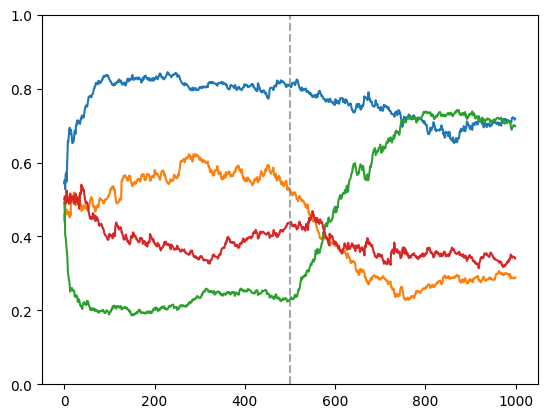

In [29]:
plt.figure()
plt.gca().set_ylim(0, 1)
plt.plot(torch.vstack([result['logits'], result2['logits']]).detach().numpy())
plt.axvline(x=500, color='grey', linestyle='--', alpha=0.7, label='500 Trials')

/var/folders/5j/f0qqpk592x36fxmyl_8vbkw40000gp/T/ipykernel_63521/1419712970.py:3: RuntimeWarning: Mean of empty slice
  plt.plot(np.nanmean(probabilities, axis=0))
/var/folders/5j/f0qqpk592x36fxmyl_8vbkw40000gp/T/ipykernel_63521/1419712970.py:4: RuntimeWarning: Mean of empty slice
  plt.fill_between(range(len(np.nanmean(probabilities, axis=0))),


TypeError: object of type 'numpy.float64' has no len()

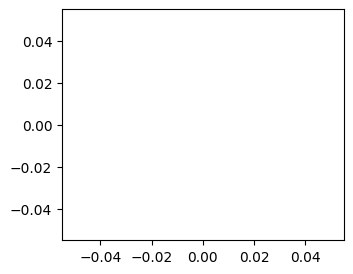

In [9]:
plt.figure(figsize=(8, 3))
plt.subplot(1, 2, 1)
plt.plot(np.nanmean(probabilities, axis=0))
plt.fill_between(range(len(np.nanmean(probabilities, axis=0))), 
                 np.nanmean(probabilities, axis=0) - np.nanstd(probabilities, axis=0) / np.sqrt(probabilities.shape[0]),
                 np.nanmean(probabilities, axis=0) + np.nanstd(probabilities, axis=0) / np.sqrt(probabilities.shape[0]),
                 alpha=0.3)
plt.xlabel('Sorted Probabilities')
plt.ylabel('Inferred Probabilities')
plt.subplot(1, 2, 2)
plt.plot(np.nanmean(variances, axis=0))
plt.fill_between(range(len(np.nanmean(variances, axis=0))), 
                 np.nanmean(variances, axis=0) - np.nanstd(variances, axis=0) / np.sqrt(variances.shape[0]),
                 np.nanmean(variances, axis=0) + np.nanstd(variances, axis=0) / np.sqrt(variances.shape[0]),
                 alpha=0.3)
plt.xlabel('Sorted Probabilities')
plt.ylabel('Variances')
plt.show()

In [65]:
outlist = []
nb_simul = 100
for nb_steps in [4, 8]:
    for i_simul in range(nb_simul):
        self.env.reset(num_trials=200, num_steps=1, num_tasks=1, reset_probas=True)
        result = self.evaluate()        
        self.env.reset(num_trials=200, num_steps=nb_steps, reset_probas=False, cond='Astar')
        test_result = self.evaluate(rnn_state=result['rnn_state'])
        max_perf = ((test_result['greedy'] * 2 - 1) == test_result['rewarded']).float().mean()
        agent_perf = ((test_result['logodds']).sign().detach() == test_result['rewarded']).float().mean()
        outlist.append([nb_steps, i_simul, float(max_perf), float(agent_perf)])
outdf = pd.DataFrame(outlist, columns=['nb_steps', 'i_simul', 'max_perf', 'agent_perf'])

/Users/csmfindling/Documents/Postdoc-Geneva/reliability_VW/reasoning/rnns/task.py:14: FutureWarning: arrays to stack must be passed as a "sequence" type such as list or tuple. Support for non-sequence iterables such as generators is deprecated as of NumPy 1.16 and will raise an error in the future.
  cues_presented = np.vstack(np.random.choice(list(cues) * (num_trials // len(cues)), size=num_trials, replace=False) for _ in range(num_tasks))


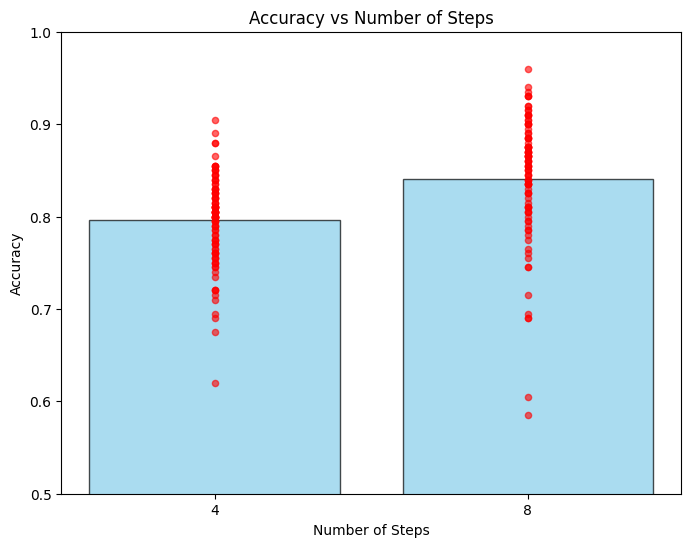

nb_steps
4    0.79600
8    0.84015
Name: agent_perf, dtype: float64

In [66]:
import matplotlib.pyplot as plt

# Group by number of steps and calculate mean accuracy
grouped = outdf.groupby('nb_steps')['agent_perf'].mean()

# Create bar plot
plt.figure(figsize=(8, 6))
bars = plt.bar([0, 1], grouped.values, alpha=0.7, color='skyblue', edgecolor='black')

# Add individual points
for pos,nb_steps in zip([0, 1], outdf['nb_steps'].unique()):
    step_data = outdf[outdf['nb_steps'] == nb_steps]['agent_perf']
    x_positions = [pos] * len(step_data)
    plt.scatter(x_positions, step_data, alpha=0.6, color='red', s=20)

plt.xlabel('Number of Steps')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Number of Steps')
plt.xticks([0, 1], ['4', '8'])
plt.ylim(0.5, 1.)
plt.show()

# Also display the grouped means
grouped

In [161]:
import pickle
[logodd_sequence_across_subjects_8, logodd_sequence_across_subjects_4] = pickle.load(
    open('/Users/csmfindling/Documents/Postdoc-Geneva/reliability_VW/reasoning/rnns/subject_tasks/subj_tasks.pkl', 'rb')
)

In [ ]:
tasks_8 = logodd_sequence_across_subjects_8[np.random.choice(np.arange(logodd_sequence_across_subjects_8.shape[0]), size=200, replace=False)]

array([[2, 0, 0, ..., 0, 3, 4],
       [4, 4, 3, ..., 2, 4, 4],
       [2, 0, 3, ..., 0, 3, 2],
       ...,
       [4, 2, 0, ..., 3, 2, 0],
       [3, 4, 3, ..., 0, 3, 2],
       [3, 3, 3, ..., 3, 2, 4]])

In [163]:
logodd_sequence_across_subjects_8.shape

(35, 120, 8)

In [227]:
from tqdm import tqdm
outlist = []
probalist = []
nb_simul = 35

for idx_simul in tqdm(range(1, 21)):

    self = Worker(
        probabilistic_task(),
        "results/source/saved_models",
        "rnn_pf_id{0}".format(idx_simul),
        "white",
        0.,
        nb_samples=-1,
        train_task="A",
        optimizer="Adam",
        init_type="xavier",
        episode_count_max=2e4,
        num_units=32,
        integration="optimal",
        loss_type="BCE",
        learn_variabilities=False
    )

    self.load_model()

    for nb_steps in [4, 8]:
        for i_simul in range(nb_simul):
            np.random.seed(i_simul * 2)
            torch.manual_seed(i_simul * 2)
            self.env.reset(num_trials=200, num_steps=1, num_tasks=1, reset_probas=True)
            result = self.evaluate()        
            
            #self.env.reset(num_trials=200, num_steps=nb_steps, reset_probas=False, cond='Astar')
            tasks = logodd_sequence_across_subjects_8[idx_simul] if nb_steps == 8 else logodd_sequence_across_subjects_4[idx_simul]      
            proba_tasks = np.round(1./(1. + np.exp(-tasks)), 1)
            squeezed_probas = np.round(self.env.probas.squeeze(), 2)
            sorter = np.argsort(squeezed_probas)
            self.env.context = torch.from_numpy(sorter[np.searchsorted(squeezed_probas[sorter], proba_tasks)])
            self.env.num_trials = 120
            self.env.num_steps = nb_steps
            self.env.cond = 'Astar'
            test_result = self.evaluate(rnn_state=result['rnn_state'])
            test_result['greedy'] = (tasks.sum(axis=1) > 0) * 1
            test_result['rewarded'] = (np.random.rand(120) < 1./(1. + np.exp(-tasks.sum(axis=1)))) * 2 - 1
            max_perf = ((test_result['greedy'] * 2 - 1) == test_result['rewarded']).mean()
            agent_perf = ((test_result['logodds']).squeeze().sign().detach().numpy() == test_result['rewarded']).mean()
            outlist.append([nb_steps, idx_simul, i_simul, float(max_perf), float(agent_perf)])    

            sorted_indices = np.argsort(result['probas'].squeeze())
            sorted_emissions = result['emission_probs'][sorted_indices]
            sorted_probas = result['probas'].squeeze()[sorted_indices]
            for i in range(len(sorted_emissions)):
                probalist.append([nb_steps, idx_simul, i_simul, float(sorted_emissions[i]), sorted_probas[i]])

outdf = pd.DataFrame(outlist, columns=['nb_steps', 'idx_simul', 'i_simul', 'max_perf', 'agent_perf'])
probadf = pd.DataFrame(probalist, columns=['nb_steps', 'idx_simul', 'i_simul', 'emission_probs', 'probas'])

  0%|          | 0/20 [00:00<?, ?it/s]/Users/csmfindling/Documents/Postdoc-Geneva/reliability_VW/reasoning/rnns/task.py:14: FutureWarning: arrays to stack must be passed as a "sequence" type such as list or tuple. Support for non-sequence iterables such as generators is deprecated as of NumPy 1.16 and will raise an error in the future.
  cues_presented = np.vstack(np.random.choice(list(cues) * (num_trials // len(cues)), size=num_trials, replace=False) for _ in range(num_tasks))
100%|██████████| 20/20 [00:43<00:00,  2.15s/it]


In [228]:
aggdf = outdf.groupby(['nb_steps', 'idx_simul'])[['agent_perf', 'max_perf']].mean().reset_index()
aggprobadf = probadf.groupby(['nb_steps', 'idx_simul', "probas"])[['emission_probs']].mean().reset_index()

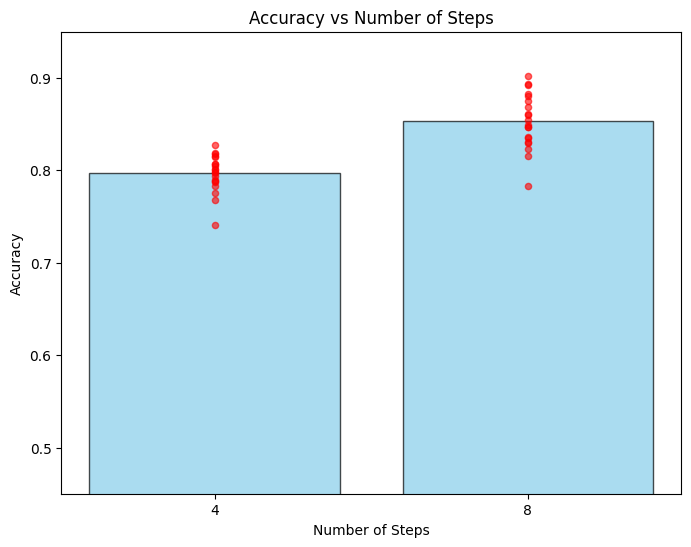

nb_steps
4    0.796857
8    0.853250
Name: agent_perf, dtype: float64

In [232]:
import matplotlib.pyplot as plt

# Group by number of steps and calculate mean accuracy
grouped = aggdf.groupby('nb_steps')['agent_perf'].mean()

# Create bar plot
plt.figure(figsize=(8, 6))
bars = plt.bar([0, 1], grouped.values, alpha=0.7, color='skyblue', edgecolor='black')

# Add individual points
for pos,nb_steps in zip([0, 1], aggdf['nb_steps'].unique()):
    step_data = aggdf[aggdf['nb_steps'] == nb_steps]['agent_perf']
    x_positions = [pos] * len(step_data)
    plt.scatter(x_positions, step_data, alpha=0.6, color='red', s=20)

plt.xlabel('Number of Steps')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Number of Steps')
plt.xticks([0, 1], ['4', '8'])
plt.ylim(0.45, .95)
plt.show()

# Also display the grouped means
grouped

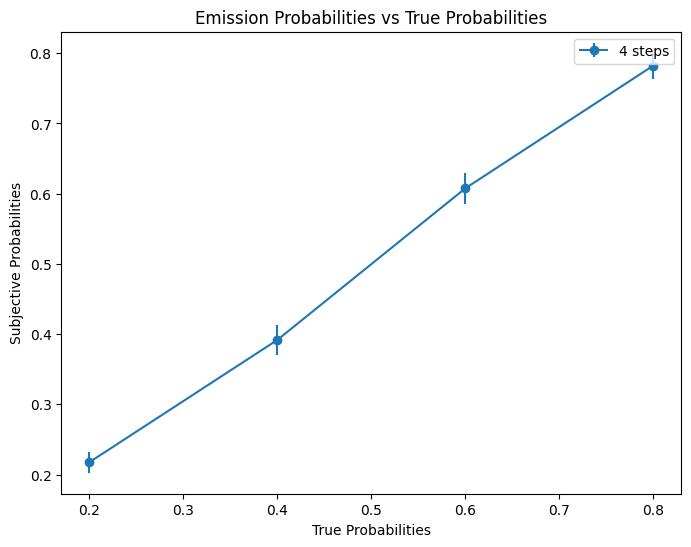

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate mean and SEM across idx_simul for each nb_steps and probas combination
plot_data = aggprobadf.groupby(['nb_steps', 'probas']).agg({
    'emission_probs': ['mean', 'std']
}).reset_index()

# Flatten column names
plot_data.columns = ['nb_steps', 'probas', 'emission_probs_mean', 'emission_probs_sem']

plt.figure(figsize=(8, 6))

# Plot for nb_steps=4
data_4 = plot_data[plot_data['nb_steps'] == 4]
plt.errorbar(data_4['probas'], data_4['emission_probs_mean'], 
             yerr=data_4['emission_probs_sem'], 
             label='4 steps', marker='o', capsize=0)

plt.xlabel('True Probabilities')
plt.ylabel('Subjective Probabilities')
plt.title('Emission Probabilities vs True Probabilities')
plt.legend()
plt.show()


In [242]:
subdata = plot_data[plot_data.nb_steps == 4]
subdata

coef_4_mean = subdata.emission_probs_mean.values
coef_4_std = subdata.emission_probs_sem.values

In [243]:
rewared_subjects_4 = aggdf[aggdf.nb_steps == 4].agent_perf.values
rewared_subjects_8 = aggdf[aggdf.nb_steps == 8].agent_perf.values

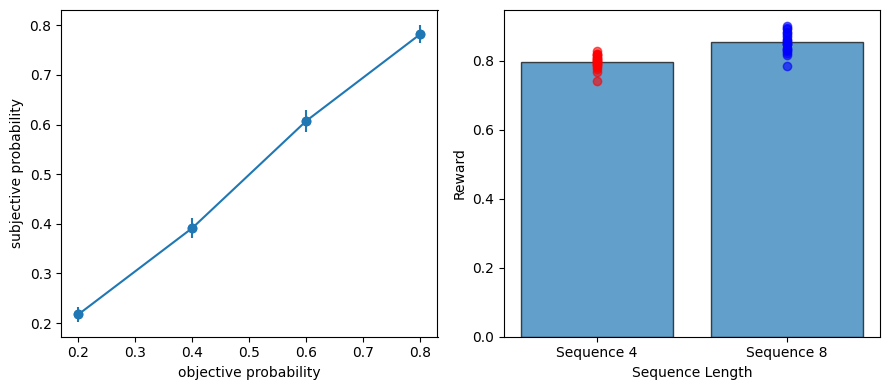

In [257]:
import matplotlib
import matplotlib.pyplot as plt

# This is the crucial line for PDF files
matplotlib.rcParams['pdf.fonttype'] = 42

# This is the equivalent for SVG files
matplotlib.rcParams['svg.fonttype'] = 'none'


plt.figure(figsize=(9, 4))
plt.subplot(1, 2, 1)
plt.scatter([0.2, 0.4, 0.6, 0.8], coef_4_mean)
plt.errorbar([0.2, 0.4, 0.6, 0.8], coef_4_mean, 
                yerr=coef_4_std, 
                label='4 steps', marker='o', capsize=0)
plt.ylabel('subjective probability')
plt.xlabel('objective probability')
plt.subplot(1, 2, 2)
plt.bar(['Sequence 4', 'Sequence 8'], [np.mean(rewared_subjects_4), np.mean(rewared_subjects_8[rewared_subjects_4 > 0.5])], alpha=0.7, edgecolor='black')
plt.scatter(['Sequence 4'] * len(rewared_subjects_4), rewared_subjects_4, alpha=0.6, color='red')
plt.scatter(['Sequence 8'] * len(rewared_subjects_8), rewared_subjects_8, alpha=0.6, color='blue')
plt.ylabel('Reward')
plt.xlabel('Sequence Length')
plt.tight_layout()
plt.savefig('/Users/csmfindling/Documents/Postdoc-Geneva/reliability_VW/expe/fig/subjects/performance_neuralHMM.pdf')
plt.show()


In [127]:
[probas[::-1], probas]

[array([0.8, 0.6, 0.4, 0.2]), array([0.2, 0.4, 0.6, 0.8])]